# Building Agents That Use Code
This notebook is part of the Hugging Face Agents Course, a free Course from beginner to expert, where you learn to build Agents.

In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login, whoami

load_dotenv(dotenv_path=".env", override=True)
token = os.environ.get("HF_TOKEN")

# Validate before logging in
try:
    login(token=token, add_to_git_credential=False)
    user = whoami()
    print(f"✅ Logged in as: {user['name']}")
except Exception as e:
    print(f"❌ Login failed: {e}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Logged in as: zaidalissa


## The @tool Decorator
### Generating a tool that retrieves the highest-rated catering
Let us imagine that Alfred has already decided on the menu for the party, but now he needs help preparing food for such a large number of guests. To do so, he would like to hire a catering service and needs to identify the highest-rated options available. Alfred can leverage a tool to search for the best catering services in his area.

Below is an example of how Alfred can use the @tool decorator to make this happen:

In [17]:
from smolagents import CodeAgent, InferenceClientModel, tool

# Let us pretend we have a function that fetches the highest-rated catering services.
@tool
def catering_service_tool(query: str) -> str:
    """
    This tool returns the highest-rated catering service in Gotham City.

    Args:
        query: A search term for finding catering services.
    """
    # Example list of catering services and their ratings
    services = {
        "Gotham Catering Co.": 4.9,
        "Wayne Manor Catering": 4.8,
        "Gotham City Events": 4.7,
    }

    # Find the highest rated catering service (simulating search query filtering)
    best_service = max(services, key=services.get)

    return best_service

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-72B-Instruct",  # Non-thinking variant, supports tool calling
    # token="hf_..."  # Add your HF token if hitting auth errors
)

agent = CodeAgent(tools=[catering_service_tool], model=model)

# Run the agent to find the best catering service
result = agent.run(
    "Can you give me the name of the highest-rated catering service in Gotham City?"
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Can you give me the name of the highest-rated catering service in Gotham City?                                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-72B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_catering_service = catering_service_tool(query="highest rated catering service in Gotham City")    
  print(highest_rated_catering_service)                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Catering Co.

Out: None

[Step 1: Duration 5.58 seconds| Input tokens: 2,081 | Output tokens: 68]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Gotham Catering Co.")                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Catering Co.

[Step 2: Duration 3.99 seconds| Input tokens: 4,328 | Output tokens: 130]

Gotham Catering Co.


## Defining a Tool as a Python Class
Generating a tool to generate ideas about the superhero-themed party
Alfred's party at the mansion is a superhero-themed event, but he needs some creative ideas to make it truly special. As a fantastic host, he wants to surprise the guests with a unique theme.

To do this, he can use an agent that generates superhero-themed party ideas based on a given category. This way, Alfred can find the perfect party theme to wow his guests.



In [14]:
from smolagents import Tool, CodeAgent, InferenceClientModel

class SuperheroPartyThemeTool(Tool):
    name = "superhero_party_theme_generator"
    description = """
    This tool suggests creative superhero-themed party ideas based on a category.
    It returns a unique party theme idea."""

    inputs = {
        "category": {
            "type": "string",
            "description": "The type of superhero party (e.g., 'classic heroes', 'villain masquerade', 'futuristic Gotham').",
        }
    }

    output_type = "string"

    def forward(self, category: str):
        themes = {
            "classic heroes": "Justice League Gala: Guests come dressed as their favorite DC heroes with themed cocktails like 'The Kryptonite Punch'.",
            "villain masquerade": "Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.",
            "futuristic Gotham": "Neo-Gotham Night: A cyberpunk-style party inspired by Batman Beyond, with neon decorations and futuristic gadgets."
        }

        return themes.get(category.lower(), "Themed party idea not found. Try 'classic heroes', 'villain masquerade', or 'futuristic Gotham'.")

# Instantiate the tool
model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",  # Non-thinking variant, supports tool calling
    # token="hf_..."  # Add your HF token if hitting auth errors
)
party_theme_tool = SuperheroPartyThemeTool()
agent = CodeAgent(tools=[party_theme_tool], model=model)

# Run the agent to generate a party theme idea
result = agent.run(
    "What would be a good superhero party idea for a 'villain masquerade' theme?"
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What would be a good superhero party idea for a 'villain masquerade' theme?                                     │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  theme_idea = superhero_party_theme_generator(category="villain masquerade")                                      
  final_answer(theme_idea)                                                                                         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.

[Step 1: Duration 3.60 seconds| Input tokens: 2,116 | Output tokens: 64]

Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.


## Simple Code Explanation

Think of this code like building a **waiter at a party** who knows themed ideas:

```
You (agent.run) → Ask a question
     ↓
Agent → Figures out HOW to answer (uses the AI model to think)
     ↓
Tool (SuperheroPartyThemeTool) → Actually looks up the answer
     ↓
Agent → Returns the final result
```

**Each piece:**
- `Tool` — A lookup table. You give it a category, it gives back a party idea
- `CodeAgent` — The "brain" that decides when and how to use the tool
- `InferenceClientModel` — The AI model doing the thinking/planning
- `agent.run(...)` — You ask the question, the whole chain kicks off

---

## What `forward` Does

`forward` is simply **the function that runs when the tool is called.** It's the mandatory method name that `smolagents` looks for — like a contract. When the agent decides to use your tool, it calls `forward` automatically.

```python
def forward(self, category: str):
    themes = { "villain masquerade": "Gotham Rogues' Ball..." }
    return themes.get(category.lower(), "not found...")
```

It's just a dictionary lookup — nothing fancy. You could name it anything internally, but `smolagents` **requires** it to be called `forward`.



## Sharing a Tool to the Hub

Sharing your custom tool with the community is easy! Simply upload it to your Hugging Face account using the push_to_hub() method.

For instance, Alfred can share his catering_service_tool to help others find the best catering services in Gotham. Here's how to do it:

In [18]:
agent.push_to_hub('zaidalissa/catering_service_tool')

README.md:   0%|          | 0.00/267 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


This agent has step_callbacks: they will be ignored by this method. 1

CommitInfo(commit_url='https://huggingface.co/spaces/zaidalissa/catering_service_tool/commit/cac6450b491bda7263eb9b5179bae4984bb178c1', commit_message='Upload agent', commit_description='', oid='cac6450b491bda7263eb9b5179bae4984bb178c1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/zaidalissa/catering_service_tool', endpoint='https://huggingface.co', repo_type='space', repo_id='zaidalissa/catering_service_tool'), pr_revision=None, pr_num=None)

## Importing a Tool from the Hub
You can easily import tools created by other users using the load_tool() function. For example, Alfred might want to generate a promotional image for the party using AI. Instead of building a tool from scratch, he can leverage a predefined one from the community:

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.                 │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "A luxurious superhero-themed party at Wayne Manor with made-up superheroes. High-res, photorealistic,  
  detailed decorations, elegant guests in superhero costumes."                                                     
  image = image_generator(prompt=prompt)                                                                           
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x10BAB0BC0>

[Step 1: Duration 14.95 seconds| Input tokens: 2,111 | Output tokens: 84]

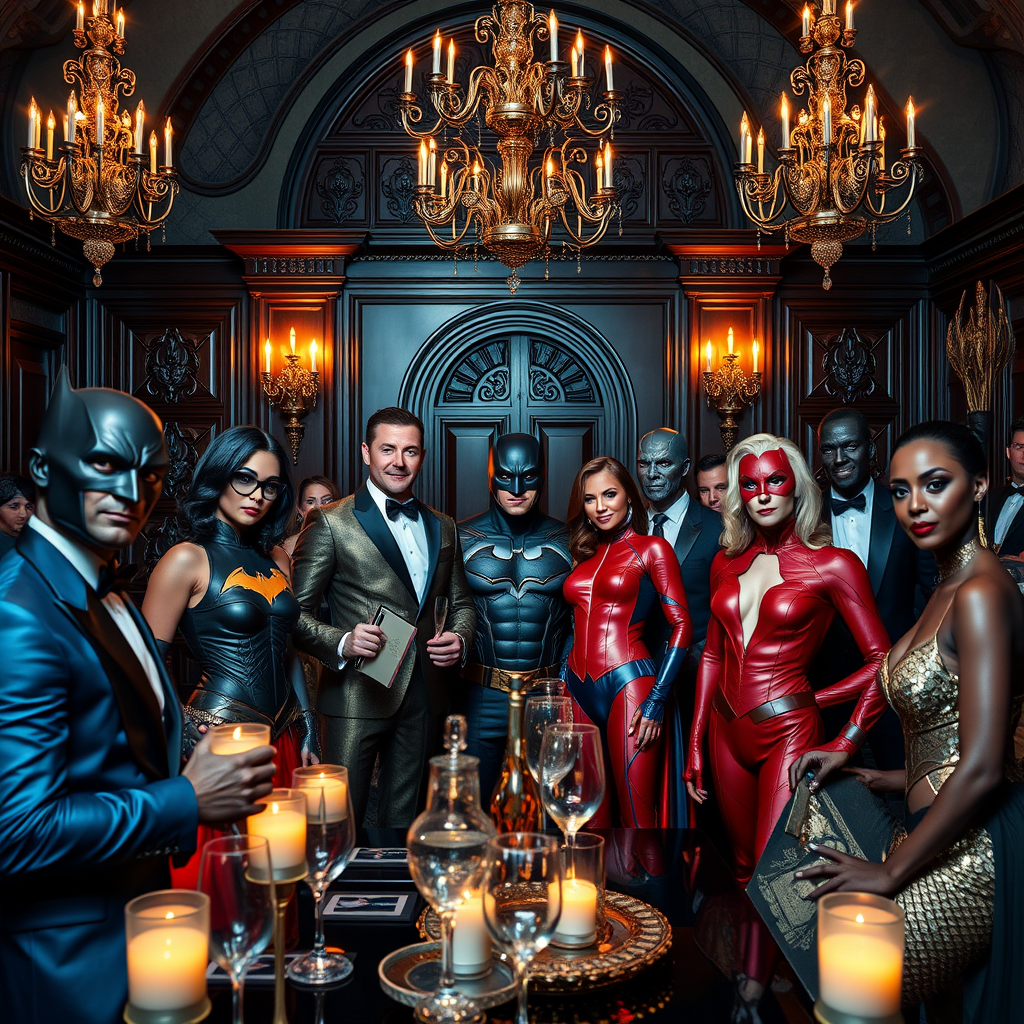

In [22]:
from smolagents import load_tool, CodeAgent, InferenceClientModel

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",  # Non-thinking variant, supports tool calling
    # token="hf_..."  # Add your HF token if hitting auth errors
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model
)

agent.run("Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.")


## Importing a Hugging Face Space as a Tool
You can also import a HF Space as a tool using Tool.from_space(). This opens up possibilities for integrating with thousands of spaces from the community for tasks from image generation to data analysis.

The tool will connect with the spaces Gradio backend using the gradio_client, so make sure to install it via pip if you don't have it already. For the party, Alfred can also use a HF Space directly for the generation of the previous annoucement AI-generated image. Let's build it!

In [23]:
!pip install gradio_client



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
from smolagents import CodeAgent, InferenceClientModel, Tool

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",  # Non-thinking variant, supports tool calling
    token=token
)

agent = CodeAgent(tools=[image_generation_tool], model=model)

agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}
)

TypeError: Client.__init__() got an unexpected keyword argument 'hf_token'

In [27]:
import gradio_client, smolagents
print(gradio_client.__version__)
print(smolagents.__version__)

2.4.0
1.24.0


In [34]:
import sys

# Uninstall current version
!{sys.executable} -m pip uninstall gradio_client -y

# Install the compatible version
!{sys.executable} -m pip install "gradio_client==1.4.0"

Found existing installation: gradio_client 1.4.0
Uninstalling gradio_client-1.4.0:
  Successfully uninstalled gradio_client-1.4.0
  Using cached gradio_client-1.4.0-py3-none-any.whl.metadata (7.1 kB)
Using cached gradio_client-1.4.0-py3-none-any.whl (319 kB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import gradio_client
print(gradio_client.__version__)  # should print 1.4.0

1.4.0


In [3]:
from smolagents import CodeAgent, InferenceClientModel, Tool

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",  # Non-thinking variant, supports tool calling
)

agent = CodeAgent(tools=[image_generation_tool], model=model)

agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}
)

Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space ✔


TypeError: argument of type 'bool' is not iterable

## What's Happening Now

The `gradio_client` version you installed still doesn't match what the **FLUX.1-schnell Space** expects. The error is deep inside gradio's schema parser — it's a known incompatibility between certain `gradio_client` builds and newer HF Spaces.

The cleanest fix is to **skip `Tool.from_space` entirely** and call the Inference API directly with a custom tool:

```python
from smolagents import CodeAgent, InferenceClientModel, Tool
from huggingface_hub import InferenceClient
import base64
from pathlib import Path

class ImageGenerationTool(Tool):
    name = "image_generator"
    description = "Generate an image from a text prompt and save it locally."
    inputs = {
        "prompt": {
            "type": "string",
            "description": "A detailed text description of the image to generate."
        }
    }
    output_type = "string"

    def forward(self, prompt: str) -> str:
        client = InferenceClient("black-forest-labs/FLUX.1-schnell")
        image = client.text_to_image(prompt)
        output_path = "generated_image.png"
        image.save(output_path)
        return f"Image saved to {output_path}"

image_generation_tool = ImageGenerationTool()

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
)

agent = CodeAgent(tools=[image_generation_tool], model=model)

agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={
        'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'
    }
)
```

Make sure `huggingface_hub` is installed:

```python
!{sys.executable} -m pip install --upgrade huggingface_hub
```

This approach is actually **more stable long-term** — you're calling the model directly via the Inference API instead of going through a Gradio Space wrapper, so you're not affected by any `gradio_client` version drama.

In [4]:
from smolagents import CodeAgent, InferenceClientModel, Tool
from huggingface_hub import InferenceClient
import base64
from pathlib import Path

class ImageGenerationTool(Tool):
    name = "image_generator"
    description = "Generate an image from a text prompt and save it locally."
    inputs = {
        "prompt": {
            "type": "string",
            "description": "A detailed text description of the image to generate."
        }
    }
    output_type = "string"

    def forward(self, prompt: str) -> str:
        client = InferenceClient("black-forest-labs/FLUX.1-schnell")
        image = client.text_to_image(prompt)
        output_path = "generated_image.png"
        image.save(output_path)
        return f"Image saved to {output_path}"

image_generation_tool = ImageGenerationTool()

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
)

agent = CodeAgent(tools=[image_generation_tool], model=model)

agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={
        'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'
    }
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Improve this prompt, then generate an image of it.                                                              │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}.      │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  improved_prompt = f"A grand superhero-themed party at Wayne Manor, with elegant decor featuring iconic comic     
  book elements and a mix of modern and classic styles. Alfred is overseeing a luxurious gala, ensuring            
  everything runs smoothly, while guests mingle and enjoy the evening in a glamorous setting. The atmosphere is    
  electric, with superheroes and villains in costume alongside notable Gotham citizens. High-quality lighting      
  illuminates the event, casting dramatic shadows and highlighting the opulence of the venue."                     
  print(improved_prompt)                                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
A grand superhero-themed party at Wayne Manor, with elegant decor featuring iconic comic book elements and a mix of
modern and classic styles. Alfred is overseeing a luxurious gala, ensuring everything runs smoothly, while guests 
mingle and enjoy the evening in a glamorous setting. The atmosphere is electric, with superheroes and villains in 
costume alongside notable Gotham citizens. High-quality lighting illuminates the event, casting dramatic shadows 
and highlighting the opulence of the venue.

Out: None

[Step 1: Duration 6.58 seconds| Input tokens: 2,120 | Output tokens: 136]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator(prompt=improved_prompt)                                                                  
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Image saved to generated_image.png

[Step 2: Duration 14.07 seconds| Input tokens: 4,617 | Output tokens: 185]

'Image saved to generated_image.png'

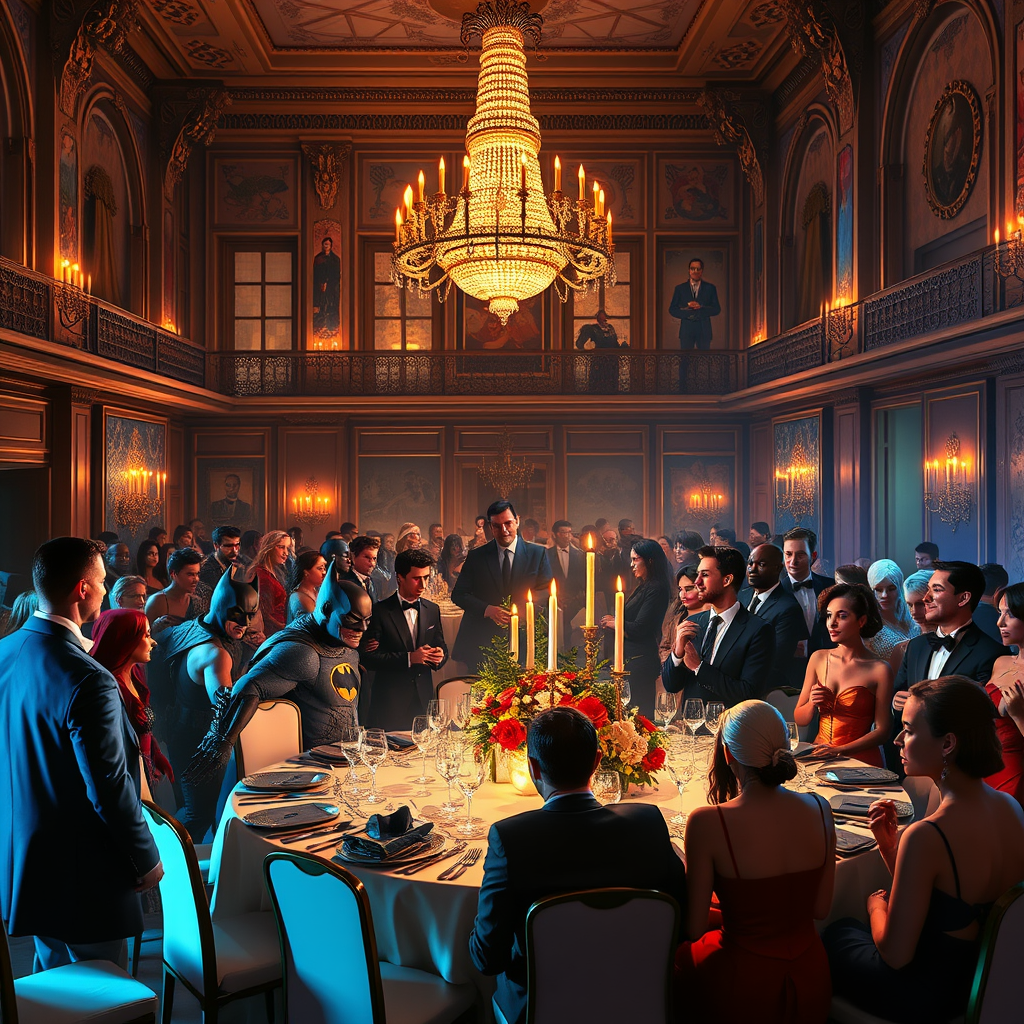

In [5]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt

image_path = 'generated_image.png'

img = PILImage.open(image_path)
img

## Importing a LangChain Tool
These tools need a SerpApi API Key.

You can easily load LangChain tools using the Tool.from_langchain() method. Alfred, ever the perfectionist, is preparing for a spectacular superhero night at Wayne Manor while the Waynes are away. To make sure every detail exceeds expectations, he taps into LangChain tools to find top-tier entertainment ideas.

By using Tool.from_langchain(), Alfred effortlessly adds advanced search functionalities to his smolagent, enabling him to discover exclusive party ideas and services with just a few commands.

Here's how he does it:

In [10]:
!pip install langchain-community google-search-results
!pip install langchain


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [langchain]/6 [langchain]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import os
from dotenv import load_dotenv
from langchain_community.agent_toolkits.load_tools import load_tools
from smolagents import CodeAgent, InferenceClientModel, Tool

load_dotenv(dotenv_path=".env", override=True)
serpapi_key = os.environ.get("SERPAPI_API_KEY")

search_tool = Tool.from_langchain(load_tools(["serpapi"], serpapi_api_key=serpapi_key)[0])

agent = CodeAgent(tools=[search_tool], model=model)

agent.run("Search for luxury entertainment ideas for a superhero-themed event, such as live performances and interactive experiences.")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Search for luxury entertainment ideas for a superhero-themed event, such as live performances and interactive   │
│ experiences.                                                                                                    │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  luxury_entertainment = search(query="luxury entertainment ideas for superhero-themed event")                     
  print(luxury_entertainment)                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
["Turning an event's invitation and program into a comic book is a relatively easy way to add colorful visuals. 
Vintage cartoons inspired MacKenzie Brown's design ...", 'Nov 3, 2017 - Explore PAWSITIVIST by Lucy\'s board 
"SUPERHEROES EVENT" on Pinterest. See more ideas about superhero, marvel superheroes, marvel avengers.', "We've 
created this guide to take you through some of the best ideas out there for decorating and styling a superhero 
theme in order to create a thrilling ...", 'LED Battery Operated Lights · Basket Filler · Superhero Mini Buttons 
(pins) · Fringed Door Curtains · Large Superhero Signs · Small Superhero ...', 'Set up interactive decor, such as a
“brick wall” for Hulk to smash or Superman to break through! To complete the cityscape feel, try cutting ...', 
'Send your guests home with superhero-themed party favors. Consider items like action figures, comic books, 
personalized masks and capes, or high-quality Marvel ...', 'Adult superhero parties might opt for events like 
superhero trivia, a costume contest, or a Hawkeye-themed shooting game. (Stack cups to hit ...', "Create an epic 
superhero birthday party with these top ideas, plus incredible invitations that'll help you share the excitement.",
'Pro Tip: You can make a “superhero lair” with black plastic tablecloths, string lights, and themed signage. What 
Are Fun Food and Drink Ideas ...', 'Superhero Cake Pops Decorate cake pops in the colors of different superheroes. 
You can make them look like Spider-Man, Batman, Wonder Woman, or ...']

Out: None

[Step 1: Duration 4.55 seconds| Input tokens: 2,088 | Output tokens: 77]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Meet and Greet")                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Meet and Greet

[Step 5: Duration 8.82 seconds| Input tokens: 18,943 | Output tokens: 815]

'Meet and Greet'